# Como juntamos os dados: as decisões, em ordem

**Projeto:** O que realmente move o preço da comida no Brasil? (SSC0957, Prática em Ciência de Dados II)

Este notebook conta como saímos de **seis fontes de dados soltas** e chegamos a **uma tabela única**. O foco não é o código, e sim **cada escolha que fizemos quando havia mais de um caminho possível**: o que poderíamos ter feito, o que fizemos e por quê.

Ainda **não fizemos a exploração nem a limpeza profunda** dos dados. O que está aqui é a etapa anterior: coletar, padronizar e juntar. A Parte 5 mostra como a tabela ficou, e a Parte 6 resume tudo e lista o que falta.

### Como ler

Cada decisão aparece num bloco com o mesmo formato:

| Marcador | Significa |
|---|---|
| 🧭 **Decisão N** | a pergunta que tivemos de responder |
| 🔀 **Opções** | os caminhos possíveis |
| ✅ **Escolha** | o que fizemos |
| 💡 **Por quê** | o motivo |
| ⚠️ **Cuidado** | a consequência que quem usa a tabela precisa conhecer |

As células de código são **exemplos pequenos, com dados de brinquedo**, que mostram o problema por trás de cada decisão. Elas rodam em qualquer computador, sem baixar nada. Os números reais citados no texto foram medidos nos notebooks `06_juncao_uf_mes.ipynb` e `07_juncao_combustiveis.ipynb`, que rodam sobre os dados completos.

### Roteiro

1. **Planejamento:** tema, alvo, fontes e recorte (decisões 1 a 6)
2. **Coleta:** como cada fonte foi baixada (decisões 7 a 17)
3. **Padronização e junção:** como seis formatos viraram uma tabela (decisões 18 a 28)
4. **Combustíveis:** a segunda junção (decisões 29 a 33)
5. **O resultado:** como a tabela ficou (decisão 34)
6. **Resumo** de todas as decisões e o que falta

## O caminho, numa figura

```
PLANEJAR            COLETAR                   PADRONIZAR                JUNTAR                        RESULTADO
(Parte 1)           (Parte 2)                 (Parte 3)                 (Partes 3 e 4)                (Parte 5)

tema                IBGE/SIDRA -> IPCA         o mês num formato só      calendário 27 UFs x 138 meses  1 tabela
alvo                INMET      -> clima        a UF sempre em sigla      + 5 junções (LEFT JOIN)        2.088 linhas
fontes              ANA        -> seca         cada fonte reduzida       filtro: só onde há alvo        108 colunas
período             IBGE/LSPA  -> safra          a UF x mês              + combustíveis (ANP)           16 UFs x 138 meses
                    BCB        -> macro
                    ANP        -> combustível

                    data/raw/  ------------->  data/interim/  ------------------------------------->  data/processed/
                    (como veio)                (uma tabela por fonte)                                  (tabela final)
```

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Acha a raiz do repositório, de onde quer que o notebook tenha sido aberto.
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
TABELAS = RAIZ / "outputs" / "tabelas"
ARQ_FATO = RAIZ / "data" / "processed" / "fato_alimentos_combustiveis_uf_mes.parquet"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

# Uma cor fixa por família de colunas: a mesma família tem a mesma cor em todos os gráficos.
CORES = {
    "ipca": "#2a78d6",   # IBGE/SIDRA
    "clima": "#eb6834",  # INMET
    "safra": "#1baf7a",  # IBGE/LSPA
    "seca": "#eda100",   # ANA
    "macro": "#e87ba4",  # BCB
    "comb": "#008300",   # ANP
}
NEUTRO = "#c3c2b7"
TINTA, TINTA_2, TINTA_3 = "#0b0b0b", "#52514e", "#898781"

plt.rcParams.update({
    "figure.figsize": (11, 3.8), "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": NEUTRO, "axes.labelcolor": TINTA_2, "text.color": TINTA,
    "xtick.color": TINTA_3, "ytick.color": TINTA_3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 9.5, "lines.linewidth": 2,
})

TEM_FATO = ARQ_FATO.exists()
print(f"raiz do projeto: {RAIZ}")
if TEM_FATO:
    print("tabela final encontrada: a Parte 5 vai mostrar os dados reais.")
else:
    print("tabela final NÃO encontrada neste computador (a pasta data/ não vai para o Git).")
    print("O notebook roda do mesmo jeito: a Parte 5 usa o dicionário de variáveis, que está no Git.")

raiz do projeto: C:\Users\sandr\OneDrive\Documentos\GitHub\trabalho_pcd2
tabela final NÃO encontrada neste computador (a pasta data/ não vai para o Git).
O notebook roda do mesmo jeito: a Parte 5 usa o dicionário de variáveis, que está no Git.


---
# Parte 1: Planejamento

Antes de baixar qualquer arquivo, precisamos decidir **o que perguntar**, **o que medir** e **com quais dados**.

### 🧭 Decisão 1: Qual tema estudar?

🔀 **Opções que discutimos**

- Ondas de calor na Europa
- Impactos do El Niño na economia
- **Relação entre clima e preço dos alimentos no Brasil**

Comparamos as opções por três critérios: **dados disponíveis**, **possibilidade de cruzar fontes diferentes** e **relevância do problema**. Também queríamos evitar fontes com que o grupo já tinha tido dificuldade em trabalhos anteriores (como o DataSUS).

✅ **Escolha:** investigar como **clima, safra, custo logístico e macroeconomia** se relacionam com o **preço dos alimentos no Brasil**.

💡 **Por quê:** os dados são públicos e em tabela (sem mapas de satélite nem PDFs complicados), existem várias fontes que podem ser cruzadas, e o preço da comida afeta diretamente o orçamento das famílias.

**Pergunta central:** *quais fatores ajudam a explicar a variação regional dos preços dos alimentos no Brasil?*

A tabela final precisa permitir testar cinco hipóteses: **H1** clima · **H2** safra · **H3** logística · **H4** macroeconomia · **H5** diferenças entre regiões.

### 🧭 Decisão 2: Como medir o "preço da comida"? (a variável-alvo)

🔀 **Opções**

| | Cesta básica do DIEESE | **IPCA de alimentos (IBGE/SIDRA)** |
|---|---|---|
| O que é | valor da cesta básica em R$, por capital | variação % mensal dos preços, por área urbana |
| Formato | relatórios mensais em **PDF**, com layout que muda entre anos | **API pública** (SIDRA), tabela pronta |
| Preço por produto | fechado ao público desde 2018 | disponível: arroz, tomate, café, carnes... |
| Cobertura | 17 capitais | 16 áreas urbanas |
| Tipo de número | valor em R$ (tem tendência, precisa deflacionar) | variação % (comparável entre meses e regiões) |

✅ **Escolha:** IPCA do grupo *Alimentação e bebidas* e de itens selecionados, por área urbana.

💡 **Por quê:** é o índice oficial de inflação, vem por API, traz o preço **por produto** e já é uma variação percentual. Ler os PDFs do DIEESE era a tarefa mais arriscada do projeto (ticket T-011) e foi abandonada.

⚠️ **Cuidado:** o IPCA só existe para **16 UFs**. A célula abaixo mostra quais entram e quais ficam de fora.

In [2]:
dim_uf = pd.read_csv(RAIZ / "data" / "processed" / "dim_uf.csv")
UFS_IPCA = ["AC", "BA", "CE", "DF", "ES", "GO", "MA", "MG", "MS", "PA", "PE", "PR", "RJ", "RS", "SE", "SP"]
dim_uf["tem_ipca"] = dim_uf["sigla_uf"].isin(UFS_IPCA)

linhas = []
for regiao, g in dim_uf.groupby("regiao"):
    linhas.append({
        "região": regiao,
        "entram (têm IPCA)": ", ".join(g.loc[g["tem_ipca"], "sigla_uf"]),
        "ficam de fora": ", ".join(g.loc[~g["tem_ipca"], "sigla_uf"]) or "—",
    })

print(f"{dim_uf['tem_ipca'].sum()} UFs com IPCA, {(~dim_uf['tem_ipca']).sum()} sem")
pd.DataFrame(linhas).set_index("região")

16 UFs com IPCA, 11 sem


,entram (têm IPCA),ficam de fora
região,,
Centro-Oeste,"DF, GO, MS",MT
Nordeste,"BA, CE, MA, PE, SE","AL, PB, PI, RN"
Norte,"AC, PA","AM, AP, RO, RR, TO"
Sudeste,"ES, MG, RJ, SP",—
Sul,"PR, RS",SC


O **Mato Grosso**, maior produtor de grãos do país, fica de fora. As UFs onde o clima afeta a produção nem sempre são as mesmas onde o preço é medido. Isso volta na lista de pendências (Parte 6).

### 🧭 Decisão 3: Com quais dados explicar o preço?

Para cada hipótese, precisávamos de pelo menos uma fonte. Avaliamos as candidatas por relevância, período coberto, frequência (queremos **mensal**), detalhe regional (queremos **por UF**) e facilidade de cruzar com as outras.

| Hipótese | Fonte avaliada | O que traz | Decisão | Motivo |
|---|---|---|---|---|
| H1 Clima | **INMET** (BDMEP) | chuva e temperatura de ~700 estações | ✅ usar | medição direta e diária, no país inteiro |
| H1 Clima | **ANA** (Monitor de Secas) | % do estado em seca e severidade | 🟡 usar com ressalva | índice pronto e validado por especialistas, mas só cobre o país inteiro a partir de 2023 |
| H2 Safra | **IBGE/LSPA** + PAM | estimativa mensal de safra por UF e produto | ✅ usar | é mensal e por UF |
| H2 Safra | CONAB | safra, estoques e custos | ❌ descartar | é **anual por ano-safra** (ex.: 2024/25); virar mês exige suposições, e o LSPA já mede o mesmo mês a mês |
| H3 Logística | **ANP** | preço de diesel, gasolina, etanol e gás de cozinha | ✅ usar | é o único custo que muda **no tempo e entre estados** |
| H3 Logística | CEPEA/ESALQ | preços na origem e frete | ⏸️ não coletada | estava na proposta, ficou para depois |
| H4 Macro | **BCB/SGS** | dólar, Selic, inflação geral, IGP-M | ✅ usar | séries oficiais, sem nenhum valor faltando |

✅ **Escolha:** seis pesquisas de cinco instituições: IBGE/SIDRA (o alvo), INMET, ANA, IBGE/LSPA, BCB e ANP. A disciplina pedia pelo menos três fontes.

💡 **Por que INMET *e* ANA?** Elas se complementam. O INMET mede o clima de cada dia (um pico de calor, uma chuva forte); a ANA resume a **seca prolongada** num índice pronto.

### 🧭 Decisão 4: O que cada linha da tabela final representa?

Cada fonte chega com um **grão** diferente. Grão é o que uma linha representa:

| Fonte | Uma linha é... |
|---|---|
| IPCA | um **item** (arroz, tomate...) numa área urbana, num mês |
| INMET | uma **estação meteorológica** numa hora |
| Safra | um **produto** numa UF, num mês |
| Seca | uma UF num mês |
| BCB | o **Brasil inteiro** num mês |
| ANP | um **combustível** numa UF, num mês |

🔀 **Opções:** município × mês · região metropolitana × mês · **UF × mês** · Brasil × mês. E, para o formato: **longo** (uma linha por item ou produto) ou **largo** (cada item ou produto vira uma coluna).

✅ **Escolha:** **UF × mês, formato largo.** Uma linha por estado por mês. A chave da tabela é o par `(sigla_uf, ano_mes)`.

💡 **Por quê:** **UF e mês são as duas únicas coisas que todas as fontes têm em comum.** Município não existe no IPCA nem na seca; Brasil × mês jogaria fora a variação regional, que é justamente a pergunta. O formato largo deixa "uma linha = um estado num mês", que é o que os modelos esperam.

⚠️ **Cuidado:** a área urbana do IPCA (ex.: Região Metropolitana de Belém) vira a UF (PA). O preço é o da capital e arredores, não do estado inteiro. A conversão usa os 2 primeiros dígitos do código IBGE, não o nome da cidade.

### 🧭 Decisão 5: Qual período analisar?

✅ **Escolha:** **janeiro de 2015 a junho de 2026, 138 meses.** Está fixado em `src/config.py` (`PERIODO_INICIO` e `PERIODO_FIM`).

💡 **Por quê:** é o período em que **todas** as fontes existem ao mesmo tempo. Junho de 2026 é o último mês que todas têm.

Mas **baixamos mais do que isso** em algumas fontes, de propósito:

| Fonte | Baixada desde | Por que a folga |
|---|---|---|
| IPCA | 2006-07 | o acumulado em 12 meses de jan/2015 precisa dos meses de 2014 |
| INMET, safra, BCB | 2014-01 | para criar variáveis defasadas (ex.: chuva de 6 meses antes) sem perder o início da janela |
| ANP | 2004-05 | a variação em 12 meses de jan/2015 precisa de jan/2014 |

⚠️ **Cuidado:** cálculos que olham para trás (acumulados, variações anuais) são feitos **na série inteira, antes do corte**. Cortando primeiro, os primeiros 12 meses ficariam vazios.

### 🧭 Decisão 6: Como organizar os arquivos para 5 pessoas trabalharem juntas?

🔀 **Opções:** cada um com seus arquivos e caminhos no próprio computador · ou uma estrutura fixa, com os dados separados por etapa.

✅ **Escolha:** três camadas de dados e um lugar único para caminhos e referências.

```
data/raw/        dado exatamente como veio da fonte: NUNCA é modificado
data/interim/    uma tabela por fonte, já limpa e com as chaves padronizadas
data/processed/  a tabela final e a tabela de referência das UFs
```

- `src/config.py` guarda **todos** os caminhos e o período. Ninguém escreve caminho absoluto no código.
- `data/processed/dim_uf.csv` é a **referência das 27 UFs** (sigla, nome, código IBGE, capital, região). Todo nome de lugar vira sigla passando por ela.
- Os dados **não vão para o Git** (são pesados). Quem clona o repositório gera tudo de novo com `python -m src.coleta.runner --completo`.

💡 **Por quê:** se um erro aparece no tratamento, basta refazer a partir de `raw/`, sem baixar tudo de novo. A Decisão 8 mostra o que acontece quando essa regra não é respeitada.

---
# Parte 2: Coleta, ou como cada fonte foi baixada

| Fonte | Como foi baixada | O que chegou |
|---|---|---|
| IBGE/SIDRA: IPCA | API do SIDRA, 168 requisições em blocos de 3 meses | 83.383 linhas, de 2006-07 a 2026-07 |
| INMET: clima | 13 arquivos ZIP anuais (~1,27 GB) | 701 estações, dados **por hora** |
| ANA: seca | API REST, uma requisição por UF | 27 UFs, série mensal |
| IBGE/LSPA: safra | API do SIDRA (tabela 6588) + PAM (tabelas 1612 e 1613) | 44.847 linhas, 11 produtos |
| BCB/SGS: macro | API do Banco Central, 5 séries | 151 meses, nenhum valor faltando |
| ANP: combustíveis | extração da base de preços da ANP (CSV) | 26.446 linhas, 8 produtos |

Todos os coletores são chamados pelo mesmo comando (`python -m src.coleta.runner`) e podem ser rodados de novo sem repetir o que já foi baixado.

## 2.1 IPCA (IBGE/SIDRA): o alvo

### 🧭 Decisão 7: De qual tabela do SIDRA tirar o IPCA?

O IBGE troca a tabela do IPCA sempre que revisa a estrutura do índice. Nenhuma tabela sozinha cobre o período todo.

🔀 **Opções**

| Opção | Problema |
|---|---|
| Só a tabela 7060 | começa em jan/2020: perderíamos 2015 a 2019 |
| Emendar com a tabela 7062 | **não serve**: a 7062 é o IPCA-15, outro índice |
| **Encadear 2938 → 1419 → 7060** | mesma pesquisa, mesmos códigos de item |

✅ **Escolha:** encadear **2938** (2006-2011), **1419** (2012-2019) e **7060** (2020-2026), buscando dois níveis territoriais: **N7** (10 regiões metropolitanas) e **N6** (6 municípios).

💡 **Por que os dois níveis:** o IPCA não tem nível "UF" (pedir o nível N3 devolve erro 404). Quem busca só N7 perde Brasília, Goiânia, Campo Grande, São Luís, Aracaju e Rio Branco.

### 🧭 Decisão 8: O que fazer com os marcadores de "sem dado" do SIDRA?

O SIDRA escreve `-` (ou `...`, `X`) quando um valor não foi publicado. A primeira versão do coletor removia esses símbolos **apagando o caractere `-` de todo o texto**. Parece inofensivo. Veja o que acontece:

In [3]:
# Valores como chegam do SIDRA: texto. Um "-" sozinho quer dizer "não publicado".
valores = pd.Series(["0.48", "-0.48", "-1.20", "-", "2.10"])

# Versão ERRADA (a primeira do coletor): apaga o "-" de qualquer lugar do texto
errado = pd.to_numeric(valores.str.replace("-", "", regex=False), errors="coerce")

# Versão CORRIGIDA: só anula o texto que é, inteiro, um marcador
MARCADORES = ["-", "...", "..", "X", ""]
certo = pd.to_numeric(valores.where(~valores.str.strip().isin(MARCADORES)), errors="coerce")

pd.DataFrame({"como veio": valores, "versão errada": errado, "versão corrigida": certo})

,como veio,versão errada,versão corrigida
0,0.48,0.48,0.48
1,-0.48,0.48,-0.48
2,-1.20,1.20,-1.20
3,-,NaN,NaN
4,2.10,2.10,2.10


Na versão errada, **toda queda de preço virou alta** (`-0.48` virou `0.48`), sem erro e sem aviso. No arquivo real, o estrago foi este:

| | Com o erro | Corrigido |
|---|---|---|
| valores negativos (deflação) | **0** | **32.696** |
| menor valor | 0,00 % | −56,62 % |
| média por mês | 3,14 % (≈ 45 % ao ano!) | 0,75 % |

✅ **Escolha:** corrigir a limpeza e **baixar tudo de novo**.

💡 **Por que baixar de novo:** o arquivo em `raw/` já tinha passado pela limpeza errada, e não havia uma cópia intacta. Foi isso que motivou a regra "nunca modificar `data/raw/`".

⚠️ **Como evitamos que o erro volte:** a junção agora **falha de propósito** se o alvo não tiver nenhum mês de deflação (em `src/tratamento/24_junta.py`). Onze anos de inflação mensal sem nenhum valor negativo é impossível.

### 🧭 Decisão 9: Identificar cada item pelo nome ou pelo código?

O campo chega assim: `"1101002.Arroz"`, com código e nome juntos.

🔀 **Opções:** agrupar pelo **nome** (`Arroz`) ou pelo **código** (`1101002`).

✅ **Escolha:** pelo **código**.

💡 **Por quê:** o IBGE **renomeia itens no meio da série**. São 40 códigos com 42 nomes diferentes: o `1111004` era "Leite pasteurizado" até 2011 e virou "Leite longa vida"; o feijão "macassar" virou "macáçar" em 2020. Agrupar pelo nome quebraria essas séries em duas.

## 2.2 INMET: clima

O INMET publica um ZIP por ano, com um arquivo por estação e **uma linha por hora**. São ~1,27 GB comprimidos.

### 🧭 Decisão 10: Como ler 1,27 GB sem travar o computador e sem ler lixo?

✅ **Escolhas:**
- **Um ano por vez, um arquivo por vez, lido direto do ZIP para a memória.** Descompactar tudo ocuparia vários GB.
- **Encontrar as colunas pelo nome, não pela posição.** O formato **mudou em 2019**: rótulos sem acento, data com `/` em vez de `-`, e "sem medição" deixou de ser `-9999` para virar campo vazio.
- **Tratar `-9999` como vazio já na leitura**, e conferir de novo depois.

💡 **Por quê:** um `-9999` que chega até uma média vira uma "temperatura" de milhares de graus negativos, e o código não reclama.

### 🧭 Decisão 11: Em que ordem transformar hora → dia → mês?

🔀 **Opções:** agregar direto de hora para mês (mais simples) · ou passar pelo dia.

✅ **Escolha:** **hora → dia → mês**, com regras próprias para cada grandeza:

| Regra | Por quê |
|---|---|
| Chuva do dia = **soma** das horas; temperatura = média, máxima e mínima | cada grandeza agrega do seu jeito |
| Um dia só vale com **pelo menos 18 horas medidas**, conferido grandeza por grandeza | é comum o pluviômetro parar e o termômetro continuar |
| Soma com `min_count=1` | sem isso, um dia **sem nenhuma medição** vira "0 mm de chuva" |
| Índices de extremo (dias sem chuva, maior sequência seca, dias de calor extremo) calculados **a partir dos dias** | depois que o mês vira um total, não dá mais para saber como a chuva se distribuiu |
| "Calor extremo" = acima do **percentil 90 da própria estação naquele mês do ano** | 32 °C é normal em Teresina e raro em Curitiba |
| Direção do vento **ficou de fora** | é um ângulo: a média de 350° e 10° dá 180°, o lado oposto |

O exemplo abaixo mostra por que os extremos precisam sair do dado diário:

In [4]:
# Um dia sem nenhuma medição: 24 horas vazias
dia_sem_medicao = pd.Series([np.nan] * 24)
print(f"soma comum de um dia sem medição:   {dia_sem_medicao.sum()} mm   <- parece que não choveu")
print(f"soma com min_count=1:               {dia_sem_medicao.sum(min_count=1)} mm   <- 'não sei', que é a verdade\n")

# Dois meses com EXATAMENTE a mesma chuva total: 90 mm
dias = pd.RangeIndex(1, 31, name="dia")
mes_a = pd.Series(3.0, index=dias)                     # 3 mm todo dia
mes_b = pd.Series(0.0, index=dias)
mes_b.loc[15] = 90.0                                   # 90 mm num único dia

def maior_sequencia_seca(chuva):
    seco = chuva < 1                                   # dia seco = menos de 1 mm
    return int(seco.groupby((~seco).cumsum()).sum().max())

pd.DataFrame({
    "chuva no mês (mm)": [mes_a.sum(), mes_b.sum()],
    "dias sem chuva": [int((mes_a < 1).sum()), int((mes_b < 1).sum())],
    "maior sequência de dias secos": [maior_sequencia_seca(mes_a), maior_sequencia_seca(mes_b)],
}, index=["mês A: chuva espalhada", "mês B: uma tempestade só"])

soma comum de um dia sem medição:   0.0 mm   <- parece que não choveu
soma com min_count=1:               nan mm   <- 'não sei', que é a verdade



,chuva no mês (mm),dias sem chuva,maior sequência de dias secos
mês A: chuva espalhada,90.0,0,0
mês B: uma tempestade só,90.0,29,15


Os dois meses têm o mesmo total, mas para uma lavoura são opostos: o mês B tem **15 dias seguidos sem chuva** (um veranico). Só o total mensal não mostraria isso.

### 🧭 Decisão 12: O que fazer onde as estações não mediram?

Depois de baixar, conferimos em quantos dias cada UF teve pelo menos uma estação funcionando. O critério era **pelo menos 90 % dos dias**.

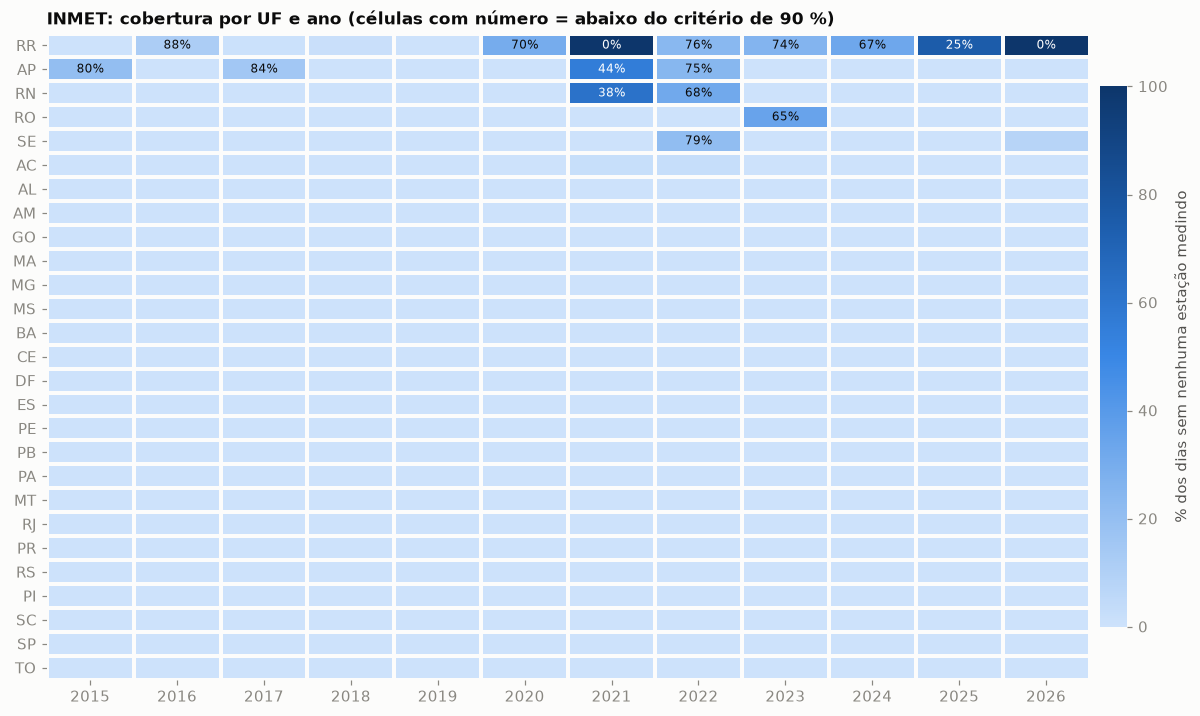

In [5]:
cob = pd.read_csv(TABELAS / "inmet_cobertura_uf_ano.csv")
cobertura = cob.pivot(index="sigla_uf", columns="ano", values="pct_cobertura")
cobertura = cobertura.loc[cobertura.mean(axis=1).sort_values().index]   # piores UFs no topo
falta = 100 - cobertura                                                  # % dos dias SEM medição

azul = LinearSegmentedColormap.from_list("azul", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
n_linhas, n_colunas = falta.shape

fig, ax = plt.subplots(figsize=(11, 6.6))
malha = ax.pcolormesh(np.arange(n_colunas + 1), np.arange(n_linhas + 1), falta.values,
                      cmap=azul, vmin=0, vmax=100, edgecolors="#fcfcfb", linewidth=1.5)
ax.set_xticks(np.arange(n_colunas) + 0.5, falta.columns)
ax.set_yticks(np.arange(n_linhas) + 0.5, falta.index)
ax.invert_yaxis()
ax.grid(False)
for lado in ax.spines.values():
    lado.set_visible(False)

# Número só nas células abaixo do critério de 90 %
for i in range(n_linhas):
    for j in range(n_colunas):
        valor = cobertura.values[i, j]
        if valor < 90:
            ax.text(j + 0.5, i + 0.5, f"{valor:.0f}%", ha="center", va="center", fontsize=8,
                    color="#ffffff" if falta.values[i, j] > 45 else TINTA)

barra = fig.colorbar(malha, ax=ax, fraction=0.025, pad=0.01)
barra.set_label("% dos dias sem nenhuma estação medindo")
barra.outline.set_visible(False)
ax.set_title("INMET: cobertura por UF e ano (células com número = abaixo do critério de 90 %)")
plt.tight_layout()
plt.show()

Dois problemas aparecem:

- **Roraima** tem praticamente uma estação funcionando. Em 2021 e 2026 ela não mediu nada. Nenhum tratamento resolve isso: o dado não existe.
- **Um buraco nacional em 2021-2022.** O Rio Grande do Norte, com 100 % nos outros anos, cai para 38 % em 2021. E 2021 é justamente o ano da crise hídrica do Centro-Sul.

🔀 **Opções:** preencher com a média histórica daquele mês ("normal climatológica") · usar outra fonte, como o NASA POWER (dados de satélite em grade, sem falha de estação) · **manter vazio e documentar**.

✅ **Escolha (por enquanto):** **manter vazio** e guardar na tabela a coluna `clima_n_estacoes`, com quantas estações mediram.

💡 **Por quê:** preencher agora esconderia a incerteza justamente no período de maior interesse. A imputação (e o NASA POWER) ficou registrada como pendência.

⚠️ **Cuidado:** a rede de estações **cresce** com o tempo (475 estações em 2014, 638 em 2026). Um "degrau" numa série de clima que coincide com um salto no número de estações é efeito da rede, não do clima.

## 2.3 ANA: Monitor de Secas

### 🧭 Decisão 13: Como obter os dados de seca?

🔀 **Opções**

| Opção | Problema |
|---|---|
| Baixar o CSV do site | não há arquivo: a página monta a tabela dentro do navegador |
| Baixar os mapas e cruzar com os municípios | exige geoprocessamento (shapefiles, `geopandas`) |
| **Usar a API que o próprio site usa** | foi encontrada lendo o código JavaScript da página |

✅ **Escolha:** a API REST aberta da ANA, **uma requisição por UF** (27 no total, menos de um minuto).

💡 **Por quê:** descobrimos que o campo `area` não é km², e sim o **% do território da UF** em seca. As categorias são **cumulativas** (S2 = "seca grave *ou pior*"). Ou seja, **a própria ANA já agrega município → UF**, e não foi preciso nenhum geoprocessamento.

### 🧭 Decisão 14: A API devolve várias versões do mesmo mês. Qual usar?

Quando a ANA revisa um mês, a API devolve **todas as versões juntas**, sem dizer qual vale. E algumas versões antigas trazem valores absurdos.

🔀 **Opções:** a primeira que aparece · o maior valor · a média · **a versão mais recente (maior `id`)**.

In [6]:
revisoes = pd.read_csv(TABELAS / "monitor_secas_revisoes_divergentes.csv")
n_meses = len(revisoes[["sigla_uf", "ano", "mes"]].drop_duplicates())
print(f"{n_meses} UF-meses chegaram com versões que discordam entre si\n")

# Exemplo real: Bahia, abril de 2015. Na escala da ANA, 10000 pontos = 100 % do território.
exemplo = revisoes[(revisoes["sigla_uf"] == "BA") & (revisoes["ano"] == 2015) & (revisoes["mes"] == 4)]
exemplo[["categoria", "id_registro", "pontos", "pontos_vigente", "descartado"]]

49 UF-meses chegaram com versões que discordam entre si



,categoria,id_registro,pontos,pontos_vigente,descartado
28,S0,711,9847.0,9847.0,False
29,S0,796,984700.0,9847.0,True
30,S0,801,9847.0,9847.0,False
31,S1,712,6650.0,6650.0,False
32,S1,797,665000.0,6650.0,True
33,S1,802,6650.0,6650.0,False
34,S2,713,1847.0,1847.0,False
35,S2,798,184700.0,1847.0,True
36,S2,803,1847.0,1847.0,False
37,S3,714,1047.0,1047.0,False


Na Bahia, em abril de 2015, uma versão antiga veio com a escala **multiplicada por 100** (`984700` em vez de `9847`, o que daria 9.847 % do território). Em junho de 2016 aparece um `123456`, claramente um valor de teste. Pegar "o maior" ou "o primeiro" importaria esses números como se fossem reais.

✅ **Escolha:** usar a **versão com maior `id`** (a vigente) e **gravar as divergências** em `outputs/tabelas/monitor_secas_revisoes_divergentes.csv`, para auditoria.

⚠️ **O que não dá para consertar, a gente marca:** um mês do Maranhão (2014-11) viola a regra cumulativa (S3 = 0 com S4 = 13). Não inventamos um valor; o mês ganhou a marca `inconsistente = True`.

## 2.4 IBGE/LSPA: safra

### 🧭 Decisão 15: Quais produtos e quais cálculos para a safra?

(A escolha entre LSPA e CONAB está na Decisão 3.)

✅ **Escolhas:**
- **Tabela 6588 (LSPA):** estimativa da safra do ano, **revista todo mês**, por UF. Complementada pela PAM (tabelas 1612 e 1613), com a produção anual realizada.
- **11 produtos** ligados à cesta de alimentos: arroz, feijão, milho, soja, trigo, café, banana, batata-inglesa, tomate, mandioca e cana-de-açúcar.
- **Somar as safras que o IBGE separa:** feijão de 1ª, 2ª e 3ª safra; milho de 1ª e 2ª; café arábica e canéfora; batata-inglesa das 3 safras.
- **Recalcular o rendimento (kg/ha)** como produção total ÷ área total, e não como média dos rendimentos de cada safra.

💡 **Por que recalcular o rendimento:** a média de rendimentos dá o mesmo peso a uma safra de mil hectares e a uma de um milhão.

⚠️ **Cuidado:** cada linha é a **estimativa da safra do ANO inteiro** vigente naquele mês, não o que foi colhido no mês. Somar 12 meses multiplica a produção por 12.

## 2.5 BCB: macroeconomia

### 🧭 Decisão 16: Quais séries usar e como transformar dados diários em mensais?

✅ **Escolhas:**

| Série (código SGS) | Frequência original | Como virou mensal |
|---|---|---|
| Dólar PTAX (1) | diária | **média do mês** e **valor do último dia** (duas colunas) |
| IPCA cheio (433) | mensal | direto |
| Selic meta (432) | diária | valor no fim do mês |
| Selic efetiva (11) | dias úteis | composta no mês |
| IGP-M (189) | mensal | direto |

💡 **Por quê:** sem controlar dólar e inflação geral, o modelo poderia atribuir ao clima o que é só perda de valor da moeda. O IPCA cheio tem uma segunda função: gera o alvo "inflação da comida acima da inflação geral" (Decisão 20).

⚠️ **Armadilha encontrada:** pedindo mais de 10 anos de uma vez, a API responde "OK" mas **devolve os dados cortados**. O coletor pede em blocos de 10 anos e confere se o período devolvido é o pedido. Os valores foram conferidos com números oficiais (ex.: dólar médio de março de 2020 = R$ 4,88).

## 2.6 ANP: combustíveis

### 🧭 Decisão 17: Quais combustíveis e quais preços manter?

A extração da ANP tem 8 produtos e dois preços: o que o posto **paga** à distribuidora e o que ele **cobra** do consumidor.

| Item | Decisão | Motivo medido |
|---|---|---|
| Diesel, Diesel S10, Gasolina, Etanol | ✅ manter | cobrem a janela inteira nas 16 UFs |
| GLP (botijão de 13 kg) | ✅ manter | é o gás de cozinha, que faz parte da própria cesta do IPCA |
| Diesel S50 | ❌ descartar | só existe em 2012 (73 linhas) |
| Gasolina aditivada | ❌ descartar | começa só em out/2020 e anda junto com a comum (correlação ~0,99) |
| GNV | ❌ descartar | falta em 45 % da grade e é combustível de carro urbano, não de frete |
| Preço de **compra** do posto | ❌ descartar | a ANP parou de publicar em 2021: a coluna "morre" no meio da série |
| Preço de **venda** ao consumidor | ✅ manter | é contínuo |

💡 **Por que combustível numa tabela sobre comida:** o diesel é o frete de toda a comida que sai da lavoura, e o GLP é o custo de cozinhar. E, ao contrário do dólar e da Selic (iguais no país inteiro), o preço do combustível **muda de um estado para outro**.

⚠️ **Pendência:** é a única fonte **sem script de download** no repositório; o CSV foi extraído à parte. Diesel e Diesel S10 são produtos diferentes (o S10 tem menos enxofre), e os dois ficaram.

---
# Parte 3: Padronização e junção

Com as seis tabelas baixadas, a pergunta passou a ser **como colocar tudo na mesma linha**. Apareceram três armadilhas, todas do tipo que **não dá erro nenhum**: só produzem um número errado.

## 3.1 O contrato das chaves

### 🧭 Decisão 18: Em que formato guardar o mês?

O mês chegou de três jeitos: texto `"2015-01"` (IPCA, clima e seca), data `2015-01-01` (safra e BCB) e período. O jeito "óbvio" de igualar é transformar tudo em texto. Veja:

In [7]:
ipca_exemplo = pd.DataFrame({"sigla_uf": ["SP", "SP"], "ano_mes": ["2015-01", "2015-02"], "ipca": [1.1, 0.8]})
safra_exemplo = pd.DataFrame({"sigla_uf": ["SP", "SP"],
                              "ano_mes": pd.to_datetime(["2015-01-01", "2015-02-01"]),
                              "producao_t": [500, 510]})

# Jeito "óbvio": converter os dois lados para texto
a = ipca_exemplo.assign(ano_mes=ipca_exemplo["ano_mes"].astype(str))
b = safra_exemplo.assign(ano_mes=safra_exemplo["ano_mes"].astype(str))    # vira "2015-01-01"
print('junção usando texto: nenhum erro, mas...')
display(a.merge(b, on=["sigla_uf", "ano_mes"], how="left"))

# Jeito escolhido: Period[M], um tipo que representa "o mês", sem dia
a = ipca_exemplo.assign(ano_mes=pd.PeriodIndex(ipca_exemplo["ano_mes"], freq="M"))
b = safra_exemplo.assign(ano_mes=safra_exemplo["ano_mes"].dt.to_period("M"))
print("junção usando Period[M]:")
display(a.merge(b, on=["sigla_uf", "ano_mes"], how="left"))

junção usando texto: nenhum erro, mas...


,sigla_uf,ano_mes,ipca,producao_t
0,SP,2015-01,1.1,NaN
1,SP,2015-02,0.8,NaN


junção usando Period[M]:


,sigla_uf,ano_mes,ipca,producao_t
0,SP,2015-01,1.1,500
1,SP,2015-02,0.8,510


Com texto, `"2015-01"` nunca encontra `"2015-01-01"`, e a coluna da safra volta **inteira vazia**, sem nenhum aviso. No dado real foram **0 de 3.726** valores preenchidos.

✅ **Escolha:** todo mês vira **`Period[M]`**, e a sigla da UF vira sempre texto de 2 letras maiúsculas.

💡 **Por quê:** como `Period[M]` não tem dia, não existe um "2015-01-01" para divergir de "2015-01".

## 3.2 A segunda armadilha: linhas que se multiplicam

A safra tem **uma linha por produto** em cada UF-mês. Juntando direto:

In [8]:
calendario = pd.DataFrame({"sigla_uf": ["SP", "SP"], "ano_mes": pd.period_range("2015-01", periods=2, freq="M")})
safra_longa = pd.DataFrame({
    "sigla_uf": ["SP"] * 6,
    "ano_mes": pd.PeriodIndex(["2015-01"] * 3 + ["2015-02"] * 3, freq="M"),
    "produto": ["arroz", "milho", "soja"] * 2,
    "producao_t": [10, 200, 300, 11, 210, 320],
})

juntado = calendario.merge(safra_longa, on=["sigla_uf", "ano_mes"], how="left")
print(f"junção direta:    {len(calendario)} linhas -> {len(juntado)} linhas (cada mês repetido uma vez por produto)")

# Solução: pivotar antes, para cada produto virar uma coluna
larga = (safra_longa.pivot_table(index=["sigla_uf", "ano_mes"], columns="produto", values="producao_t")
         .add_prefix("safra_producao_t_").rename_axis(columns=None).reset_index())
juntado_ok = calendario.merge(larga, on=["sigla_uf", "ano_mes"], how="left")
print(f"pivotando antes:  {len(calendario)} linhas -> {len(juntado_ok)} linhas")
juntado_ok

junção direta:    2 linhas -> 6 linhas (cada mês repetido uma vez por produto)
pivotando antes:  2 linhas -> 2 linhas


,sigla_uf,ano_mes,safra_producao_t_arroz,safra_producao_t_milho,safra_producao_t_soja
0,SP,2015-01,10.0,200.0,300.0
1,SP,2015-02,11.0,210.0,320.0


No dado real, com 11 produtos, a tabela saltaria de **3.726 para 40.986 linhas**, e a taxa de preenchimento (79,6 %) pareceria saudável. Com os combustíveis (5 produtos) aconteceria o mesmo.

✅ **Escolha:** **toda fonte com mais de uma linha por UF-mês é pivotada antes de juntar**, e um verificador roda depois de **cada** junção.

O verificador fica em `src/tratamento/chaves.py` e tem três funções:

| Função | O que faz |
|---|---|
| `padroniza_chaves` | converte a UF e o mês para o formato combinado, venham como vierem |
| `valida_chaves` | recusa UF fora do padrão, mês que não seja `Period[M]` e chave repetida |
| `checa_join` | compara o número de linhas antes e depois e a taxa de preenchimento; **interrompe a execução** se as linhas mudaram ou se nada casou |

💡 **Por quê:** transforma um erro silencioso num erro que aparece.

## 3.3 Reduzindo cada fonte a UF × mês

### IPCA

### 🧭 Decisão 19: Quais itens do IPCA entram na tabela?

São 40 códigos de item, e nem todos existem no período inteiro em todas as UFs.

✅ **Escolha:** os **17 códigos com cobertura completa** na janela (2.088 linhas cada; o 18º já cai para 92 %). Cada um vira duas colunas: `ipca_var_*` (variação %) e `ipca_peso_*` (peso no orçamento das famílias).

| Nível | Itens |
|---|---|
| Grupo | Alimentação e bebidas (**o alvo**) |
| Subgrupos | farinhas, açúcares, hortaliças, carnes, carnes industrializadas, aves e ovos, leites e derivados |
| Subitens | arroz, batata-inglesa, tomate, frango inteiro, frango em pedaços, leite longa vida, pão francês, óleo de soja, café moído |

⚠️ **Cuidado:** os itens estão em **três níveis que se encaixam**: o frango inteiro está dentro de "aves e ovos", que está dentro de "alimentação". **Não some as colunas de peso**, porque o frango seria contado duas vezes. As colunas servem para comparar lado a lado ("o arroz subiu mais que o grupo?").

### 🧭 Decisão 20: Qual número usar como alvo?

🔀 **Opções:** a variação do mês · a variação acumulada em 12 meses · a variação acima da inflação geral.

✅ **Escolha:** **as três**, em colunas separadas, porque cada uma responde a uma pergunta diferente.

| Coluna | Cálculo | Serve para |
|---|---|---|
| `ipca_var_alimentacao` | variação % no mês | **alvo principal** |
| `ipca_var_alimentacao_acum12` | 12 meses **compostos** | suavizar a sazonalidade (a série mensal troca de sinal quase todo mês) |
| `ipca_var_alimentacao_relativa` | alimentos − IPCA cheio | quanto a comida subiu **além** da inflação geral |

⚠️ O acumulado é **multiplicado, não somado**:

In [9]:
doze_meses = pd.Series([1.0] * 12)     # alta de 1 % em cada um dos 12 meses

somado = doze_meses.sum()
composto = ((1 + doze_meses / 100).prod() - 1) * 100
print(f"somando:  {somado:.2f} %")
print(f"compondo: {composto:.2f} %   <- o correto: cada alta incide sobre o preço que já subiu")

somando:  12.00 %
compondo: 12.68 %   <- o correto: cada alta incide sobre o preço que já subiu


### Clima

### 🧭 Decisão 21: Como transformar ~700 estações num número por UF?

🔀 **Opções**

| Opção | Problema |
|---|---|
| Soma entre estações | não tem sentido físico: somar a chuva mensal de ~100 estações do RS daria ~50.000 mm |
| Média entre estações | uma estação com sensor quebrado puxa o valor da UF inteira |
| **Mediana entre estações** | ignora a estação com defeito |
| Média ponderada pela produção agrícola de cada região | mais fiel ao mecanismo econômico, mas é um trabalho à parte (ticket T-022) |

In [10]:
# 5 estações de uma UF num mês. A última está com o pluviômetro com defeito.
chuva_estacoes = pd.Series([118, 124, 131, 127, 980],
                           index=["estação 1", "estação 2", "estação 3", "estação 4", "estação 5 (defeito)"])

print(chuva_estacoes.to_string(), "\n")
print(f"soma:    {chuva_estacoes.sum():>5.0f} mm   <- nenhum lugar da UF teve essa chuva")
print(f"média:   {chuva_estacoes.mean():>5.0f} mm   <- puxada pela estação com defeito")
print(f"mediana: {chuva_estacoes.median():>5.0f} mm   <- o valor típico da UF")

estação 1              118
estação 2              124
estação 3              131
estação 4              127
estação 5 (defeito)    980 

soma:     1480 mm   <- nenhum lugar da UF teve essa chuva
média:     296 mm   <- puxada pela estação com defeito
mediana:   127 mm   <- o valor típico da UF


✅ **Escolha:** **mediana**, com regras antes e depois:

- **Antes de agregar:** estação-mês com **menos de 70 % dos dias medidos vira vazio** (22,8 % das estação-mês). Um mês com 5 dias medidos não representa o mês.
- **Na tabela:** a coluna `clima_n_estacoes` conta quantas estações entraram na mediana.
- **Ficaram de fora** a máxima e a mínima **absolutas**: a mediana dos recordes de cada estação não descreve nem o extremo nem o típico.

⚠️ **Cuidado:** em RR, AP e AC a mediana sai de 1 a 3 estações; ela descreve aquelas estações, não o estado. E a ponderação pela produção (T-022) **ainda não foi feita**.

### Safra

### 🧭 Decisão 22: Quais medidas de safra levar?

O LSPA tem 5 medidas por produto: área plantada, área colhida, produção, rendimento e a **revisão %** da estimativa em relação ao mês anterior.

✅ **Escolha:** 2 medidas × 11 produtos = **22 colunas**: `safra_producao_t_*` (o nível) e `safra_revisao_pct_*` (a revisão). As outras três continuam em `data/interim/` para uso futuro.

💡 **Por que a revisão:** é ela que **se mexe quando a lavoura quebra**; o nível da produção quase não muda dentro do ano. Levar as 55 colunas traria mais ruído que informação.

⚠️ **Um corte na revisão:** o maior valor bruto passava de **15 milhões %** (divisão por uma estimativa anterior quase zero). Os valores foram **limitados a ±50 %** (winsorização): 99,1 % ficaram intactos, e só a cauda absurda foi cortada.

### 🧭 Decisão 23: O que fazer com os vazios da safra?

Um vazio na safra quase sempre quer dizer **"essa UF não planta esse produto"** (ex.: trigo no Pará). Mas o significado muda de coluna para coluna:

In [11]:
safra = pd.DataFrame({
    "sigla_uf": ["PA", "PA", "PR", "PR"],
    "ano_mes": pd.PeriodIndex(["2020-01", "2020-02"] * 2, freq="M"),
    "safra_producao_t_trigo": [np.nan, np.nan, 3_200_000, 3_150_000],
    "safra_revisao_pct_trigo": [np.nan, np.nan, np.nan, -1.6],
})
print("como vem:")
display(safra)

tratada = safra.copy()
# O Pará não planta trigo: 0 tonelada é literalmente verdade.
tratada["safra_producao_t_trigo"] = tratada["safra_producao_t_trigo"].fillna(0)
# A revisão continua vazia: não existe revisão de algo que não existe (nem em janeiro, que não tem mês anterior).
print("depois da decisão:")
display(tratada)

como vem:


,sigla_uf,ano_mes,safra_producao_t_trigo,safra_revisao_pct_trigo
0,PA,2020-01,NaN,NaN
1,PA,2020-02,NaN,NaN
2,PR,2020-01,3200000.0,NaN
3,PR,2020-02,3150000.0,-1.6


depois da decisão:


,sigla_uf,ano_mes,safra_producao_t_trigo,safra_revisao_pct_trigo
0,PA,2020-01,0.0,NaN
1,PA,2020-02,0.0,NaN
2,PR,2020-01,3200000.0,NaN
3,PR,2020-02,3150000.0,-1.6


✅ **Escolha:**
- `safra_producao_t_*`: vazio vira **0**. Zero tonelada é verdade, e como a grade do LSPA é completa, o vazio nunca é falha de medição.
- `safra_revisao_pct_*`: **continua vazio**. Zero diria "a estimativa não mudou", que é outra afirmação. Essa coluna também é vazia em **todo janeiro**, porque não há mês anterior dentro da mesma safra.

### Seca

### 🧭 Decisão 24: O que fazer com os meses em que a UF não era monitorada?

O Monitor de Secas **começou no Nordeste** e chegou aos outros estados aos poucos:

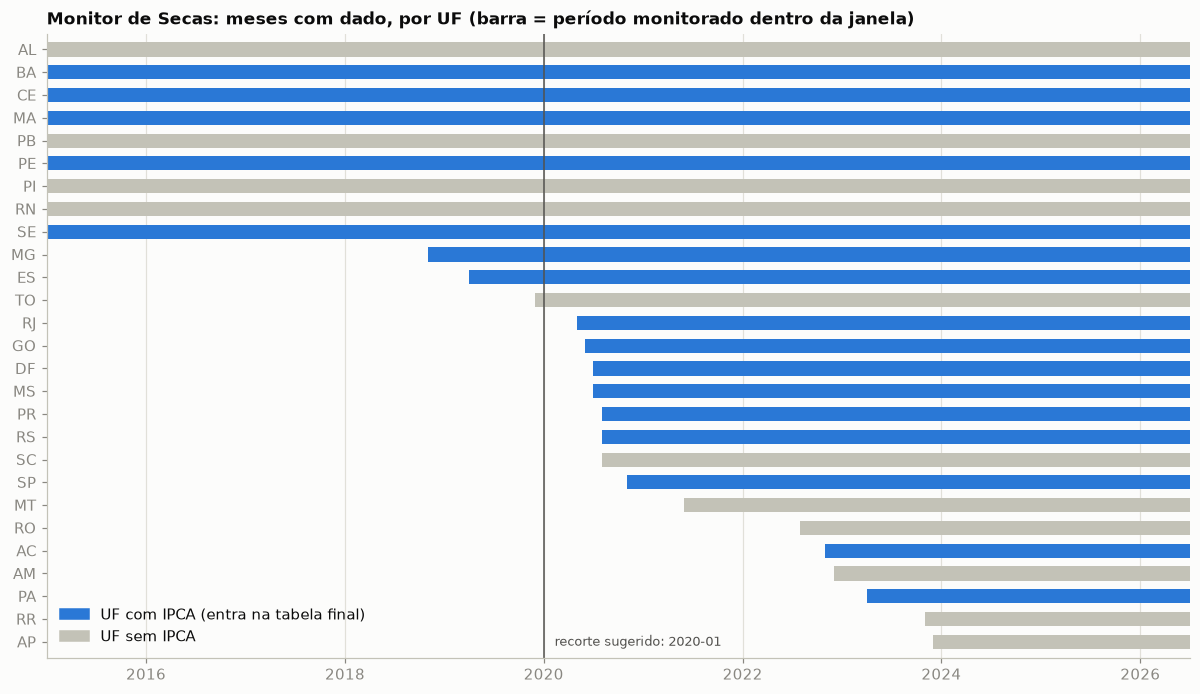

In [12]:
cob_seca = pd.read_csv(TABELAS / "cobertura_monitor_secas.csv")
cob_seca["inicio"] = pd.PeriodIndex(cob_seca["primeiro_mes"], freq="M").to_timestamp()
cob_seca = cob_seca.sort_values(["inicio", "sigla_uf"], ascending=False).reset_index(drop=True)

inicio_janela = mdates.date2num(pd.Timestamp("2015-01-01"))
fim_janela = mdates.date2num(pd.Timestamp("2026-07-01"))
corte = mdates.date2num(pd.Timestamp("2020-01-01"))

fig, ax = plt.subplots(figsize=(11, 6.4))
for i, linha in cob_seca.iterrows():
    esquerda = mdates.date2num(linha["inicio"])
    cor = CORES["ipca"] if linha["sigla_uf"] in UFS_IPCA else NEUTRO
    ax.barh(i, fim_janela - esquerda, left=esquerda, height=0.62, color=cor)

ax.axvline(corte, color=TINTA_2, linewidth=1)
ax.text(corte + 40, 0, "recorte sugerido: 2020-01", color=TINTA_2, fontsize=8.5, va="center")
ax.set_yticks(range(len(cob_seca)), cob_seca["sigla_uf"])
ax.set_xlim(inicio_janela, fim_janela)
ax.set_ylim(-0.7, len(cob_seca) - 0.3)
ax.xaxis_date()
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=CORES["ipca"], label="UF com IPCA (entra na tabela final)"),
                   Patch(color=NEUTRO, label="UF sem IPCA")],
          loc="lower left", frameon=False)
ax.set_title("Monitor de Secas: meses com dado, por UF (barra = período monitorado dentro da janela)")
plt.tight_layout()
plt.show()

Das 3.726 linhas UF × mês da janela, **1.358 (36 %) são de antes de a UF entrar no programa**. Nas 16 UFs do alvo, a cobertura muda muito conforme o recorte:

| Recorte | % das linhas com seca medida |
|---|---|
| 2015-01 a 2026-06 | 65,8 % |
| 2018-01 a 2026-06 | 77,9 % |
| **2020-01 a 2026-06** | **90,5 %** |
| 2024-01 a 2026-06 | 100 % |

🔀 **Opções:** preencher com 0 ("sem seca") · apagar as linhas sem medição · **manter vazio e criar uma marca de "monitorado"**.

Por que o zero é perigoso:

In [13]:
# Um mês de 2017: duas UFs do Nordeste (medidas, em seca forte) e duas do Sul (ainda não monitoradas)
seca_2017 = pd.DataFrame({"sigla_uf": ["CE", "PE", "PR", "RS"],
                          "seca_severidade_media": [4.5, 3.9, np.nan, np.nan]})
seca_2017["seca_monitorado"] = seca_2017["seca_severidade_media"].notna()
display(seca_2017)

print(f"média do que foi medido:  {seca_2017['seca_severidade_media'].mean():.2f}")
print(f"média com vazio = 0:      {seca_2017['seca_severidade_media'].fillna(0).mean():.2f}"
      "   <- inventa que PR e RS estavam sem seca")

,sigla_uf,seca_severidade_media,seca_monitorado
0,CE,4.5,True
1,PE,3.9,True
2,PR,NaN,False
3,RS,NaN,False


média do que foi medido:  4.20
média com vazio = 0:      2.10   <- inventa que PR e RS estavam sem seca


✅ **Escolha:** **manter vazio** e incluir a coluna `seca_monitorado` (verdadeiro/falso).

💡 **Por quê:** aqui o vazio significa **"ninguém estava medindo"**, e não "não houve seca". Com zero, o modelo aprenderia que o Sul não tinha seca antes de 2020, e passaria a confundir "seca" com "ser do Nordeste", já que até 2018 só o Nordeste tem dado.

⚠️ **Recomendação registrada no dicionário:** quem usar seca como variável explicativa deve **filtrar por `seca_monitorado`** ou **recortar a partir de 2020-01**.

### Macroeconomia

### 🧭 Decisão 25: Como colocar uma série nacional numa tabela por UF?

✅ **Escolha:** **repetir** o valor do Brasil em todas as UFs no mesmo mês (a junção usa só o mês). Entram 5 colunas: IPCA cheio, dólar médio, dólar no fim do mês, Selic e IGP-M.

⚠️ **Cuidado:** essas colunas são **idênticas em todas as UFs** num mesmo mês. Elas explicam variação **no tempo**, nunca **diferença entre estados**.

## 3.4 A junção

### 🧭 Decisão 26: Por qual tabela começar e que tipo de junção usar?

🔀 **Opções**

| Opção | Problema |
|---|---|
| Começar pelo IPCA e usar INNER JOIN | cada junção descarta linhas sem avisar; no fim não dá para saber o que se perdeu, nem onde |
| **Começar por um calendário completo e usar só LEFT JOIN** | nada some no meio; a perda acontece num único filtro, no fim, e é contada |

✅ **Escolha:** um **calendário-espinha** com todas as combinações de **27 UFs × 138 meses = 3.726 linhas**, e cinco LEFT JOINs:

```
calendário 27 UFs x 138 meses  (3.726 linhas)
  + IPCA   por UF e mês  -> preenche  56,0 %  (o alvo só existe em 16 UFs)
  + clima  por UF e mês  -> preenche  96,9 %
  + safra  por UF e mês  -> preenche 100,0 %
  + seca   por UF e mês  -> preenche  63,6 %
  + macro  só por mês    -> preenche 100,0 %  (mesmo valor em todas as UFs)
  -> checa_join depois de CADA junção: as 3.726 linhas se mantêm nos cinco passos
  -> filtro final: fica só onde há alvo -> 2.088 linhas
```

### 🧭 Decisão 27: Como nomear as colunas para não haver conflito?

🔀 **Opções:** deixar o pandas resolver nomes repetidos com sufixos (`_x`, `_y`) · **dar um prefixo por fonte antes de juntar**.

✅ **Escolha:** prefixos `ipca_`, `clima_`, `safra_`, `seca_`, `macro_` (e depois `comb_`). Colunas repetidas sem utilidade, como `ano` e `mes` que vinham na seca e no clima, foram **descartadas** em vez de renomeadas.

💡 **Por quê:** o nome da coluna já diz de onde ela veio. `temp_media_x` não diz nada.

### 🧭 Decisão 28: Quais linhas ficam na tabela final?

✅ **Escolha:** só as linhas **com alvo**: as 16 UFs do IPCA, nos meses em que o IPCA existe. Sem alvo, não há o que explicar.

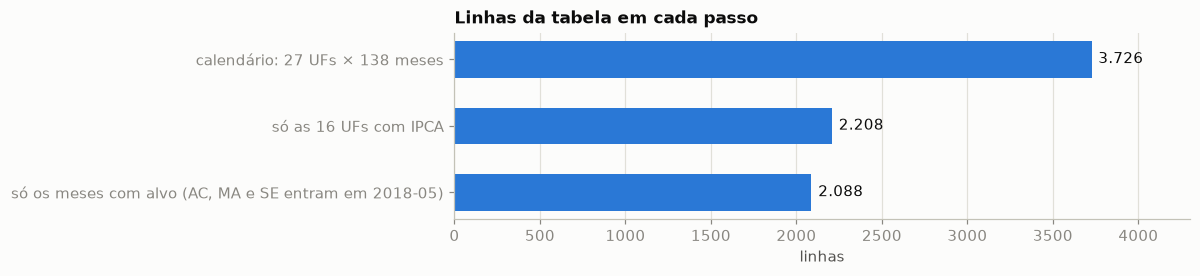

In [14]:
etapas = pd.Series({
    "calendário: 27 UFs × 138 meses": 27 * 138,
    "só as 16 UFs com IPCA": 16 * 138,
    "só os meses com alvo (AC, MA e SE entram em 2018-05)": 16 * 138 - 3 * 40,
})

fig, ax = plt.subplots(figsize=(11, 2.6))
posicoes = np.arange(len(etapas))[::-1]
ax.barh(posicoes, etapas.values, color=CORES["ipca"], height=0.55)
for y, v in zip(posicoes, etapas.values):
    ax.text(v + 40, y, f"{v:,}".replace(",", "."), va="center", color=TINTA)
ax.set_yticks(posicoes, etapas.index)
ax.set_xlim(0, 4300)
ax.grid(axis="y", visible=False)
ax.set_xlabel("linhas")
ax.set_title("Linhas da tabela em cada passo")
plt.tight_layout()
plt.show()

A conta fecha exatamente: 16 UFs × 138 meses = 2.208. Acre, Maranhão e Sergipe só entraram no IPCA em maio de 2018, e faltam 40 meses para cada um: 2.208 − 120 = **2.088 linhas**.

⚠️ **Cuidado para a próxima etapa:** variáveis defasadas (ex.: chuva de 3 meses antes) devem ser calculadas **no calendário completo, antes deste filtro**, senão os primeiros meses de AC, MA e SE ficam sem passado. O calendário completo está salvo em `data/processed/calendario_uf_mes.parquet`.

**Resultado desta etapa:** `fato_alimentos_uf_mes.parquet`, com **2.088 linhas × 89 colunas**.

---
# Parte 4: Combustíveis, a segunda junção

Os combustíveis entraram depois, **acrescentados à tabela que já estava pronta**. Vieram com decisões novas e com uma armadilha que o verificador de junção não detecta.

### 🧭 Decisão 29: O que fazer com linhas repetidas na fonte?

A ANP traz **182 casos** em que a mesma UF, mês e produto aparecem mais de uma vez. Quase todos são de abril de 2026 (duas rodadas de coleta); o resto são linhas soltas com **um único posto**.

🔀 **Opções:** apagar as repetidas e ficar com uma (qual?) · média simples · **média ponderada pelo número de postos pesquisados**.

Exemplo real, o GLP no Pará em fevereiro de 2008:

In [15]:
glp_pa = pd.DataFrame({
    "linha da fonte": ["linha solta", "coleta normal"],
    "postos pesquisados": [1, 674],
    "preço médio (R$)": [3.00, 32.95],
})
display(glp_pa)

simples = glp_pa["preço médio (R$)"].mean()
ponderada = ((glp_pa["preço médio (R$)"] * glp_pa["postos pesquisados"]).sum()
             / glp_pa["postos pesquisados"].sum())
print(f"média simples:   R$ {simples:.2f}   <- 1 posto vale o mesmo que 674")
print(f"média ponderada: R$ {ponderada:.2f}   <- cada posto vale o mesmo")

,linha da fonte,postos pesquisados,preço médio (R$)
0,linha solta,1,3.00
1,coleta normal,674,32.95


média simples:   R$ 17.98   <- 1 posto vale o mesmo que 674
média ponderada: R$ 32.91   <- cada posto vale o mesmo


✅ **Escolha:** **média ponderada pelo número de postos** (`quantidade_registros`).

💡 **Por quê:** uma regra só resolve os dois casos: a rodada grande pesa mais que a pequena, e o posto solto vale 1/675 do mês. A média simples errava esse mês em **45 %**.

### 🧭 Decisão 30: Como calcular a variação mensal numa série com meses faltando?

A ANP **não tem coleta** em alguns meses (33 dos 138, para os combustíveis líquidos). Veja a gasolina em São Paulo, em 2018:

In [16]:
# As linhas que a fonte tem: abril, maio e junho de 2018 não existem
gasolina_sp = pd.DataFrame({
    "ano_mes": pd.PeriodIndex(["2018-01", "2018-02", "2018-03", "2018-07"], freq="M"),
    "preco": [4.04, 4.05, 4.03, 4.30],
})

# Jeito ingênuo: compara cada linha com a linha de cima
ingenuo = gasolina_sp.assign(var_mensal_pct=(gasolina_sp["preco"] / gasolina_sp["preco"].shift(1) - 1) * 100)
print("variação calculada sobre as linhas que existem:")
display(ingenuo.round(2))

# Jeito escolhido: primeiro completa a grade de meses, depois calcula
meses = pd.period_range("2018-01", "2018-07", freq="M")
grade = gasolina_sp.set_index("ano_mes").reindex(meses).rename_axis("ano_mes").reset_index()
grade["var_mensal_pct"] = (grade["preco"] / grade["preco"].shift(1) - 1) * 100
print("variação calculada sobre a grade completa de meses:")
display(grade.round(2))

variação calculada sobre as linhas que existem:


,ano_mes,preco,var_mensal_pct
0,2018-01,4.04,NaN
1,2018-02,4.05,0.25
2,2018-03,4.03,-0.49
3,2018-07,4.30,6.70


variação calculada sobre a grade completa de meses:


,ano_mes,preco,var_mensal_pct
0,2018-01,4.04,NaN
1,2018-02,4.05,0.25
2,2018-03,4.03,-0.49
3,2018-04,NaN,NaN
4,2018-05,NaN,NaN
5,2018-06,NaN,NaN
6,2018-07,4.30,NaN


Na primeira tabela, julho aparece com alta de quase **7 % "no mês"**, mas a comparação é com **março**, quatro meses antes. Não é erro de conta, é erro de rótulo, e nenhum verificador de junção pega.

✅ **Escolha:** calcular variações **só depois de completar a grade de meses**. O mês ausente vira uma linha vazia, e a variação dele (e a do mês seguinte) nasce vazia, que é a verdade.

### 🧭 Decisão 31: Preencher os meses sem coleta?

🔀 **Opções:** interpolar · repetir o último preço (*forward fill*) · zero · **manter vazio e marcar**.

✅ **Escolha:** **manter vazio**, com **duas** colunas de marcação:
- `comb_observado_liquidos`: houve coleta de diesel, gasolina ou etanol naquele mês?
- `comb_observado`: houve coleta de qualquer produto, inclusive GLP?

💡 **Por quê:** interpolar inventaria preço em ~23 % das linhas e apagaria justamente os choques de preço. São **duas** marcas porque a ANP faz **duas pesquisas**, com falhas em meses diferentes: os líquidos faltam em 33 meses, o GLP em 15, e só 10 meses não têm nada.

### 🧭 Decisão 32: Refazer a junção inteira ou acrescentar à tabela pronta?

✅ **Escolha:** **acrescentar**, com um único LEFT JOIN sobre a tabela de 2.088 linhas e a mesma verificação.

Resultado conferido: **2.088 → 2.088 linhas**, **89 → 108 colunas** (19 novas) e as 89 colunas anteriores **idênticas** às de antes.

### 🧭 Decisão 33: Como saber se os preços agregados da ANP estão certos?

Havia uma segunda extração da mesma base, bem mais detalhada (**96.049 coletas individuais**, posto a posto), mas cheia de buracos.

🔀 **Opções:** usar essa extração como fonte · ignorá-la · **usá-la como testemunha**.

✅ **Escolha:** **testemunha**. Para cada UF-mês com pelo menos 20 coletas, comparamos a média das coletas com o preço agregado.

| Resultado | Valor |
|---|---|
| UF-meses comparados | 1.149 |
| Correlação | acima de 0,99 em todos os produtos |
| Erro típico (mediana do erro absoluto) | **0,61 %** |

💡 **Por quê:** duas extrações diferentes dando o mesmo número é uma validação forte, e raramente existe uma segunda medição para confrontar.

---
# Parte 5: O resultado, ou como a tabela ficou

**Arquivo:** `data/processed/fato_alimentos_combustiveis_uf_mes.parquet`

| | |
|---|---|
| Linhas | **2.088** (uma por UF por mês) |
| Colunas | **108** |
| UFs | 16: AC, BA, CE, DF, ES, GO, MA, MG, MS, PA, PE, PR, RJ, RS, SE, SP |
| Período | 2015-01 a 2026-06 (138 meses) |
| Chave | `(sigla_uf, ano_mes)`, sem nenhuma repetição |

### 🧭 Decisão 34: Como documentar o que cada coluna significa?

✅ **Escolha:** um **dicionário de variáveis gerado pelo próprio código**, com uma linha por coluna: descrição, unidade, fonte, grão original, % de vazios e, para **toda** coluna com algum vazio, **o que aquele vazio significa**. O código falha se alguma coluna com mais de 40 % de vazios ficar sem justificativa.

As células abaixo leem esse dicionário (`outputs/tabelas/dicionario_variaveis_combustiveis.csv`, que está no Git).

In [17]:
dic = pd.read_csv(TABELAS / "dicionario_variaveis_combustiveis.csv")
dic["familia"] = dic["coluna"].str.extract(r"^(ipca|clima|safra|seca|macro|comb)_")[0].fillna("chave")

NOMES_FAMILIA = {
    "chave": "identificação (UF, mês, região)",
    "ipca": "preço dos alimentos (o alvo)",
    "clima": "clima",
    "safra": "safra",
    "seca": "seca",
    "macro": "macroeconomia",
    "comb": "combustíveis",
}

familias = (
    dic.groupby("familia", sort=False)
    .agg(colunas=("coluna", "size"),
         fonte=("fonte", lambda s: " · ".join(sorted(set(s)))),
         colunas_com_vazio=("pct_nulos", lambda s: int((s > 0).sum())))
    .rename(index=NOMES_FAMILIA)
    .rename_axis("família")
)
print(f"{len(dic)} colunas documentadas, {int((dic['pct_nulos'] == 0).sum())} delas sem nenhum vazio")
familias

108 colunas documentadas, 61 delas sem nenhum vazio


,colunas,fonte,colunas_com_vazio
família,,,
"identificação (UF, mês, região)",6,IBGE (dim_uf),0
preço dos alimentos (o alvo),36,IBGE/SIDRA · IBGE/SIDRA + BCB,1
clima,11,INMET,10
safra,22,IBGE/LSPA,11
seca,9,ANA (Monitor de Secas),8
macroeconomia,5,BCB/SGS,0
combustíveis,19,ANP (Levantamento de Preços de Combustíveis),17


### Onde estão os vazios

O gráfico mostra só as colunas que têm algum vazio, na cor da sua família:

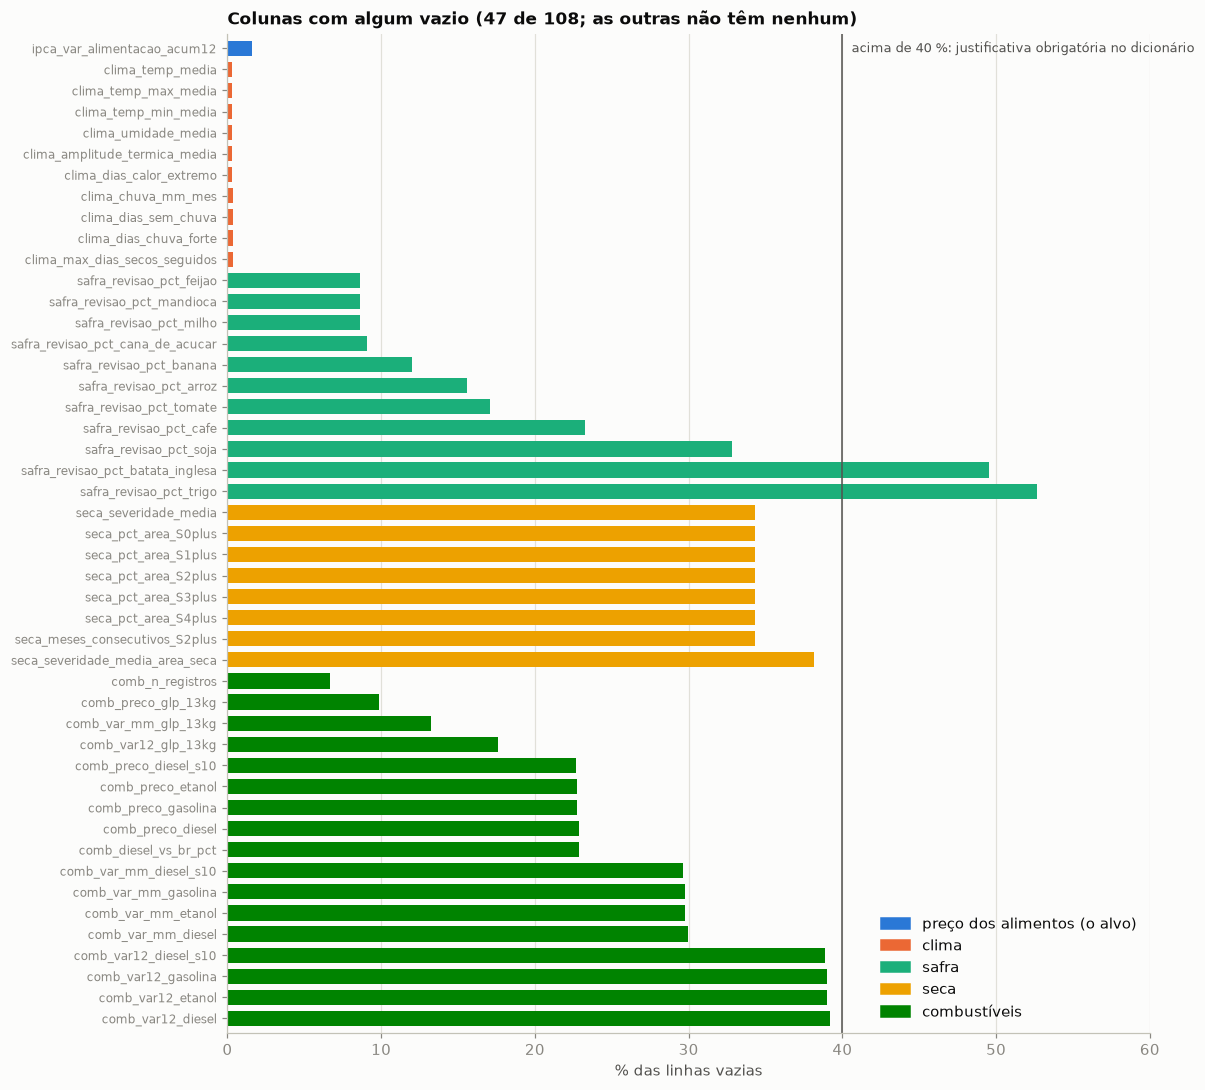

In [18]:
ordem = {familia: i for i, familia in enumerate(CORES)}
com_vazio = dic[dic["pct_nulos"] > 0].copy()
com_vazio["ordem"] = com_vazio["familia"].map(ordem)
com_vazio = com_vazio.sort_values(["ordem", "pct_nulos"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 10))
posicoes = np.arange(len(com_vazio))[::-1]
ax.barh(posicoes, com_vazio["pct_nulos"], color=com_vazio["familia"].map(CORES), height=0.72)
ax.set_yticks(posicoes, com_vazio["coluna"], fontsize=8)
ax.set_ylim(-0.7, len(com_vazio) - 0.3)
ax.set_xlim(0, 60)

ax.axvline(40, color=TINTA_2, linewidth=1)
ax.text(40.6, len(com_vazio) - 1, "acima de 40 %: justificativa obrigatória no dicionário",
        color=TINTA_2, fontsize=8.5, va="center")

presentes = [f for f in CORES if f in set(com_vazio["familia"])]
ax.legend(handles=[Patch(color=CORES[f], label=NOMES_FAMILIA[f]) for f in presentes],
          loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
ax.set_xlabel("% das linhas vazias")
ax.set_title(f"Colunas com algum vazio ({len(com_vazio)} de {len(dic)}; as outras não têm nenhum)")
plt.tight_layout()
plt.show()

Os vazios se concentram em poucas famílias, e **cada vazio significa uma coisa diferente**:

| Família | % vazio | O vazio significa | Pode virar 0? |
|---|---|---|---|
| `seca_*` | 34 a 38 % | a UF **não era monitorada** naquele mês | **Não**: inventaria ausência de seca |
| `comb_preco_*` | ~23 % (GLP ~10 %) | **mês sem pesquisa** da ANP | **Não**: seria combustível de graça |
| `comb_var_mm_*` e `comb_var12_*` | ~30 % e ~39 % | falta o mês atual **ou** o mês de comparação | **Não** |
| `safra_revisao_pct_*` | 9 a 53 % | é janeiro, ou a UF não planta o produto | **Não**: 0 = "a estimativa não mudou" |
| `safra_producao_t_*` | 0 % | (não há vazio) | **já virou 0**: a UF não planta |
| `clima_*` | 0,3 % | nenhuma estação passou do corte de 70 % | Não |
| `ipca_var_alimentacao_acum12` | 1,6 % | primeiros meses de AC, MA e SE, ainda sem 12 meses de histórico | Não: é o começo da série |

### A tabela reconhece o que sabemos que aconteceu

Uma junção pode **rodar** e mesmo assim estar **errada**. Por isso, além dos testes de estrutura (chave única, 2.088 linhas, mês no formato certo, preços dentro de faixas possíveis, alvo com deflação), conferimos eventos históricos:

| Evento conhecido | O que a tabela mostra |
|---|---|
| Seca histórica do Ceará (jan/2017) | 100 % do estado em seca grave ou pior; severidade 4,52 de 5 |
| Alta dos alimentos na pandemia | pico de **18,1 % em 12 meses** em nov/2020 |
| Estação chuvosa no Norte e Centro-Oeste | chuva mediana de 226 mm em janeiro, contra 13 mm em agosto |
| Choque do diesel após a invasão da Ucrânia | **+62 % em 12 meses** em jul/2022 e −34 % em jul/2023 |

### Dois primeiros sinais que a junção revelou

- **O diesel antecipa a comida.** A correlação entre a variação anual do diesel e a dos alimentos é 0,42 no mesmo mês e sobe para **0,49 quando o diesel é adiantado em 4 meses**, o formato esperado de um repasse de custo de frete.
- **O combustível varia entre estados; o dólar não.** O Acre paga em média **20 % a mais** pelo diesel que a mediana do país; o Paraná, 5 % a menos.

⚠️ Correlação não é causa. Esses sinais são pontos de partida para a análise, não conclusões.

### Olhando a tabela de verdade

As duas células abaixo só mostram dados se o arquivo final existir neste computador.

In [19]:
if not TEM_FATO:
    print("Arquivo não encontrado:", ARQ_FATO.relative_to(RAIZ))
    print("Para gerar: python -m src.coleta.runner --completo")
    print("(o CSV da ANP precisa estar em data/raw/combustiveis/combustivel.csv; ver Decisão 17)")
else:
    fato = pd.read_parquet(ARQ_FATO)
    if not isinstance(fato["ano_mes"].dtype, pd.PeriodDtype):
        fato["ano_mes"] = pd.PeriodIndex(fato["ano_mes"].astype(str), freq="M")

    checagens = {
        "linhas": len(fato),
        "colunas": fato.shape[1],
        "UFs": fato["sigla_uf"].nunique(),
        "meses": fato["ano_mes"].nunique(),
        "chaves repetidas": int(fato.duplicated(["sigla_uf", "ano_mes"]).sum()),
        "meses com deflação no alvo": int((fato["ipca_var_alimentacao"] < 0).sum()),
    }
    display(pd.Series(checagens, name="valor").to_frame())

    amostra = ["sigla_uf", "ano_mes", "ipca_var_alimentacao", "ipca_var_alimentacao_acum12",
               "clima_chuva_mm_mes", "clima_n_estacoes", "safra_revisao_pct_milho",
               "seca_severidade_media", "seca_monitorado", "macro_dolar_ptax_medio",
               "comb_preco_diesel", "comb_observado_liquidos"]
    with pd.option_context("display.max_columns", None):
        display(fato[amostra].sample(8, random_state=1).sort_values(["sigla_uf", "ano_mes"]))

Arquivo não encontrado: data\processed\fato_alimentos_combustiveis_uf_mes.parquet
Para gerar: python -m src.coleta.runner --completo
(o CSV da ANP precisa estar em data/raw/combustiveis/combustivel.csv; ver Decisão 17)


In [20]:
if not TEM_FATO:
    print("(os gráficos com os dados reais aparecem quando a tabela final existir)")
else:
    fato_ord = fato.sort_values(["sigla_uf", "ano_mes"])
    mediana_uf = fato_ord.groupby("ano_mes")[["ipca_var_alimentacao", "ipca_var_alimentacao_acum12"]].median()
    eixo = mediana_uf.index.to_timestamp()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
    ax1.axhline(0, color=NEUTRO, linewidth=1)
    ax1.plot(eixo, mediana_uf["ipca_var_alimentacao"], color=CORES["ipca"], linewidth=1.5)
    ax1.set_title("Inflação de alimentos no mês (mediana das 16 UFs, %)")
    ax2.axhline(0, color=NEUTRO, linewidth=1)
    ax2.plot(eixo, mediana_uf["ipca_var_alimentacao_acum12"], color=CORES["ipca"])
    ax2.set_title("Inflação de alimentos acumulada em 12 meses (mediana das 16 UFs, %)")
    for ax in (ax1, ax2):
        ax.grid(axis="x", visible=False)
    plt.tight_layout()
    plt.show()

    defasagens = list(range(13))
    correl = [fato_ord.groupby("sigla_uf")["comb_var12_diesel"].shift(k).corr(fato_ord["ipca_var_alimentacao_acum12"])
              for k in defasagens]
    melhor = int(np.nanargmax(correl))

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(defasagens, correl, color=CORES["comb"], marker="o", markersize=6)
    ax.annotate(f"máximo: {melhor} meses (r = {correl[melhor]:.2f})", (melhor, correl[melhor]),
                textcoords="offset points", xytext=(8, 8), color=TINTA)
    ax.set_xlabel("quantos meses o diesel foi adiantado")
    ax.set_ylabel("correlação")
    ax.set_title("Variação do diesel em 12 meses × inflação de alimentos em 12 meses")
    plt.tight_layout()
    plt.show()

(os gráficos com os dados reais aparecem quando a tabela final existir)


---
# Parte 6: Resumo de todas as decisões

In [21]:
decisoes = pd.DataFrame([
    ("Planejamento", "Qual tema estudar?",
     "calor na Europa · El Niño e economia · clima e preço da comida no Brasil",
     "clima e preço da comida no Brasil", "dados disponíveis, fontes cruzáveis e tema relevante"),
    ("Planejamento", "Como medir o preço da comida?",
     "cesta básica do DIEESE (PDF) · IPCA de alimentos (IBGE/SIDRA)",
     "IPCA de alimentos", "API pública, preço por produto e já é variação %"),
    ("Planejamento", "Com quais dados explicar o preço?",
     "INMET · ANA · LSPA · CONAB · ANP · CEPEA · BCB",
     "INMET, ANA (com ressalva), LSPA, ANP e BCB", "mensais e por UF; a CONAB é anual por ano-safra"),
    ("Planejamento", "O que cada linha representa?",
     "município · região metropolitana · UF · Brasil; formato longo · largo",
     "UF × mês, formato largo", "UF e mês são as únicas chaves comuns a todas as fontes"),
    ("Planejamento", "Qual período?", "—",
     "2015-01 a 2026-06 (138 meses), com folga antes", "período em que todas as fontes existem; folga para acumulados e defasagens"),
    ("Planejamento", "Como organizar os arquivos?", "cada um no seu computador · estrutura comum",
     "raw → interim → processed, config.py e dim_uf.csv", "refazer etapas sem baixar de novo; caminhos num lugar só"),
    ("Coleta", "De qual tabela do SIDRA tirar o IPCA?", "só 7060 · emendar com 7062 · 2938 + 1419 + 7060",
     "encadear 2938, 1419 e 7060, níveis N6 + N7", "a 7060 começa em 2020; a 7062 é outro índice (IPCA-15)"),
    ("Coleta", 'Como limpar os marcadores de "sem dado"?', 'apagar o caractere "-" · anular só o texto que é marcador',
     "anular só o marcador inteiro e baixar tudo de novo", "a versão antiga apagava o sinal de menos: deflação virava inflação"),
    ("Coleta", "Identificar item por nome ou código?", "nome · código",
     "código", "o IBGE renomeia itens no meio da série"),
    ("Coleta", "Como ler 1,27 GB do INMET?", "descompactar tudo · um ano por vez na memória",
     "um ano e um arquivo por vez; colunas pelo nome; -9999 = vazio", "memória limitada; o formato muda em 2019"),
    ("Coleta", "Em que ordem agregar o clima?", "hora → mês · hora → dia → mês",
     "hora → dia → mês, extremos calculados nos dias", "sequência seca e calor extremo não saem do total mensal"),
    ("Coleta", "O que fazer onde as estações não mediram?", "normal climatológica · NASA POWER · manter vazio",
     "manter vazio e guardar clima_n_estacoes", "não esconder a incerteza; imputação fica pendente"),
    ("Coleta", "Como obter os dados de seca?", "CSV do site · mapas + geoprocessamento · API do site",
     "API REST da ANA, uma chamada por UF", "a ANA já entrega o % do território da UF em seca"),
    ("Coleta", "Qual versão usar quando a ANA revisa um mês?", "primeira · maior valor · média · mais recente",
     "a mais recente (maior id)", "versões antigas têm escala errada e valores de teste"),
    ("Coleta", "Quais produtos e cálculos de safra?", "—",
     "LSPA 6588 + PAM; 11 produtos; safras somadas; rendimento recalculado", "média de rendimentos ignora o tamanho de cada safra"),
    ("Coleta", "Como tornar mensais as séries do BCB?", "—",
     "5 séries; dólar médio e de fim de mês; blocos de 10 anos", "a API corta respostas longas sem avisar"),
    ("Coleta", "Quais combustíveis e preços manter?", "8 produtos · preço de compra e de venda",
     "diesel, diesel S10, gasolina, etanol e GLP; só preço de venda", "os outros não cobrem a janela; o preço de compra some em 2021"),
    ("Junção", "Em que formato guardar o mês?", "texto · data · Period[M]",
     "Period[M] + verificação depois de cada junção", '"2015-01" não casa com "2015-01-01" e não dá erro'),
    ("Junção", "Quais itens do IPCA entram?", "40 códigos",
     "os 17 com cobertura completa", "só eles existem em todas as UFs e meses"),
    ("Junção", "Qual número usar como alvo?", "variação no mês · acumulada em 12 meses · acima da inflação geral",
     "as três, em colunas separadas", "cada uma responde a uma pergunta"),
    ("Junção", "Como juntar ~700 estações por UF?", "soma · média · mediana · ponderada pela produção",
     "mediana, descartando estação-mês com < 70 % dos dias", "resiste a sensor com defeito; ponderação fica para o T-022"),
    ("Junção", "Quais medidas de safra levar?", "5 medidas × 11 produtos",
     "produção e revisão % (22 colunas), revisão limitada a ±50 %", "a revisão sinaliza quebra de safra; cauda de 15 milhões %"),
    ("Junção", "O que fazer com vazios da safra?", "tudo 0 · tudo vazio · depende da coluna",
     "produção vazia = 0; revisão continua vazia", '"não planta" = 0 t é verdade; revisão inexistente não é 0'),
    ("Junção", "E com meses sem monitoramento de seca?", "preencher com 0 · apagar linhas · vazio + marca",
     "manter vazio + seca_monitorado", 'vazio = ninguém mediu, não "sem seca"'),
    ("Junção", "Como juntar séries nacionais?", "—",
     "repetir o valor do Brasil em todas as UFs", "explicam variação no tempo, não entre estados"),
    ("Junção", "Por onde começar a junção?", "IPCA + INNER JOIN · calendário + LEFT JOIN",
     "calendário 27 UFs × 138 meses + LEFT JOIN", "nenhuma linha some no meio; a perda é contada no fim"),
    ("Junção", "Como evitar nomes repetidos?", "sufixos _x/_y · prefixo por fonte",
     "prefixo por fonte (ipca_, clima_...)", "o nome da coluna diz de onde ela veio"),
    ("Junção", "Quais linhas ficam?", "27 UFs · só onde há alvo",
     "16 UFs com alvo: 2.088 linhas", "sem alvo não há o que explicar"),
    ("Combustíveis", "O que fazer com linhas repetidas?", "apagar · média simples · média ponderada",
     "média ponderada pelo número de postos", "a média simples chegava a errar 45 %"),
    ("Combustíveis", "Como calcular variação com meses faltando?", "sobre as linhas existentes · sobre a grade completa",
     "sobre a grade completa de meses", 'senão a "variação mensal" compara meses distantes'),
    ("Combustíveis", "Preencher meses sem coleta?", "interpolar · repetir o último · zero · vazio + marca",
     "vazio + comb_observado e comb_observado_liquidos", "interpolar inventaria ~23 % dos preços"),
    ("Combustíveis", "Refazer a junção ou acrescentar?", "refazer tudo · acrescentar",
     "um LEFT JOIN sobre a tabela pronta", "as 89 colunas anteriores ficam intactas"),
    ("Combustíveis", "Como validar os preços agregados?", "usar a extração detalhada como fonte · ignorar · testemunha",
     "testemunha: 1.149 UF-meses comparados", "erro típico de 0,61 %"),
    ("Documentação", "Como documentar as colunas?", "—",
     "dicionário gerado pelo código, com o significado de cada vazio", "cada vazio é uma afirmação diferente sobre o mundo"),
], columns=["etapa", "pergunta", "opções consideradas", "escolha", "motivo"])
decisoes.index = pd.RangeIndex(1, len(decisoes) + 1, name="nº")

(decisoes.style
 .set_properties(**{"text-align": "left", "white-space": "normal", "vertical-align": "top"})
 .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("vertical-align", "top")]}]))

,etapa,pergunta,opções consideradas,escolha,motivo
nº,,,,,
1,Planejamento,Qual tema estudar?,calor na Europa · El Niño e economia · clima e preço da comida no Brasil,clima e preço da comida no Brasil,"dados disponíveis, fontes cruzáveis e tema relevante"
2,Planejamento,Como medir o preço da comida?,cesta básica do DIEESE (PDF) · IPCA de alimentos (IBGE/SIDRA),IPCA de alimentos,"API pública, preço por produto e já é variação %"
3,Planejamento,Com quais dados explicar o preço?,INMET · ANA · LSPA · CONAB · ANP · CEPEA · BCB,"INMET, ANA (com ressalva), LSPA, ANP e BCB",mensais e por UF; a CONAB é anual por ano-safra
4,Planejamento,O que cada linha representa?,município · região metropolitana · UF · Brasil; formato longo · largo,"UF × mês, formato largo",UF e mês são as únicas chaves comuns a todas as fontes
5,Planejamento,Qual período?,—,"2015-01 a 2026-06 (138 meses), com folga antes",período em que todas as fontes existem; folga para acumulados e defasagens
6,Planejamento,Como organizar os arquivos?,cada um no seu computador · estrutura comum,"raw → interim → processed, config.py e dim_uf.csv",refazer etapas sem baixar de novo; caminhos num lugar só
7,Coleta,De qual tabela do SIDRA tirar o IPCA?,só 7060 · emendar com 7062 · 2938 + 1419 + 7060,"encadear 2938, 1419 e 7060, níveis N6 + N7",a 7060 começa em 2020; a 7062 é outro índice (IPCA-15)
8,Coleta,"Como limpar os marcadores de ""sem dado""?","apagar o caractere ""-"" · anular só o texto que é marcador",anular só o marcador inteiro e baixar tudo de novo,a versão antiga apagava o sinal de menos: deflação virava inflação
9,Coleta,Identificar item por nome ou código?,nome · código,código,o IBGE renomeia itens no meio da série


## O que ainda falta e o que pede cuidado

Esta etapa **juntou** os dados; ela **não** fez a exploração nem a limpeza profunda. Antes de modelar, vale ter em mente:

### Limitações conhecidas

| Limitação | Efeito | O que já existe para lidar com ela |
|---|---|---|
| IPCA só em 16 UFs (MT, maior produtor de grãos, fica de fora) | o preço é medido longe de onde a comida é produzida | clima ponderado pela produção (T-022) é o caminho |
| AC, MA e SE só a partir de 2018-05 | painel desbalanceado | a conta está documentada (2.088 linhas) |
| A seca só cobre o país inteiro a partir de 2023 | 34 % de vazios em `seca_*` | `seca_monitorado`; recorte em 2020-01 |
| Buraco do INMET em 2021-2022 e em Roraima | clima incerto justamente na crise hídrica de 2021 | `clima_n_estacoes`; imputação pendente |
| ANP sem coleta em 33 meses (líquidos) | ~23 % de vazios nos preços | `comb_observado_liquidos` |
| Macro igual em todas as UFs | não explica diferenças regionais | `comb_diesel_vs_br_pct` traz a dimensão espacial |

### Próximos passos

1. **Exploração e limpeza profunda** (T-030): distribuições, valores extremos, sazonalidade, correlações.
2. **Variáveis defasadas** (T-023): chuva, seca e diesel de 1 a 6 meses antes, calculadas no calendário completo, antes do filtro.
3. **Clima ponderado pela produção** (T-022): o preço do feijão em SP depende da chuva onde o feijão é plantado, não da chuva em SP.
4. **Pendências de coleta:** colocar o script de download da ANP no repositório; investigar os 33 meses sem coleta; avaliar o NASA POWER para os buracos do INMET.

### Onde está o detalhe técnico

| Assunto | Arquivo |
|---|---|
| Código da junção | [`src/tratamento/24_junta.py`](../src/tratamento/24_junta.py) e [`src/tratamento/25_combustiveis.py`](../src/tratamento/25_combustiveis.py) |
| Verificador de chaves | [`src/tratamento/chaves.py`](../src/tratamento/chaves.py) |
| Agregação do clima | [`src/tratamento/21_clima_uf_mes.py`](../src/tratamento/21_clima_uf_mes.py) |
| Junção passo a passo, com os dados reais | [`06_juncao_uf_mes.ipynb`](06_juncao_uf_mes.ipynb) e [`07_juncao_combustiveis.ipynb`](07_juncao_combustiveis.ipynb) |
| Desenho da junção | [`docs/analise_juncao_uf_mes.md`](../docs/analise_juncao_uf_mes.md) |
| Dicionário de variáveis | [`outputs/tabelas/dicionario_variaveis_combustiveis.csv`](../outputs/tabelas/dicionario_variaveis_combustiveis.csv) |